In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json
import gc
import warnings
from PIL import Image
import kagglehub

# Настройка визуализации
plt.style.use('bmh')
%matplotlib inline


from scipy.stats import skew, kurtosis, zscore, binned_statistic_2d
from statsmodels.tsa.seasonal import seasonal_decompose


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, f1_score
from catboost import CatBoostRegressor
from tsfresh.feature_extraction import extract_features, MinimalFCParameters


In [3]:
path = "/kaggle/input/datasets/yuriykatser/power-transformers-fdd-and-rul"
def load_data(data_type, split_value):
    
    
    labels_rul = pd.read_csv(os.path.join(path, f"labels_rul_{data_type}.csv"))
    
    
    data_files = glob.glob(os.path.join(path, f"data_{data_type}", "*.csv"))
    data = (
        pd.concat(
            [pd.read_csv(f).assign(id=os.path.basename(f), split=split_value) for f in data_files], 
            ignore_index=True
        )
        .merge(labels_rul, on="id", how="left") 
    )
    return data

train_data = load_data("train", 0)
test_data = load_data("test", 1)

In [4]:
train_data[train_data['id'] == "2_trans_1893.csv"]

,H2,CO,C2H4,C2H2,id,split,predicted
0,0.001596,0.012012,0.007399,0.000040,2_trans_1893.csv,0,1093
1,0.001598,0.012023,0.007405,0.000040,2_trans_1893.csv,0,1093
2,0.001600,0.012035,0.007410,0.000040,2_trans_1893.csv,0,1093
3,0.001602,0.012048,0.007415,0.000040,2_trans_1893.csv,0,1093
4,0.001604,0.012060,0.007421,0.000040,2_trans_1893.csv,0,1093
...,...,...,...,...,...,...,...
415,0.002893,0.030337,0.010167,0.000176,2_trans_1893.csv,0,1093
416,0.002902,0.030435,0.010189,0.000177,2_trans_1893.csv,0,1093
417,0.002911,0.030532,0.010210,0.000178,2_trans_1893.csv,0,1093
418,0.002919,0.030629,0.010232,0.000179,2_trans_1893.csv,0,1093


In [5]:
train_data['predicted'].unique()

array([1093,  553,  565,  837,  507,  525,  542,  536,  764,  863,  467,
        548,  547,  479,  611,  781,  871,  770,  865,  633,  598,  493,
        492,  822,  793,  490,  546,  815,  813,  482,  453,  738,  471,
        423,  475,  715,  366,  568,  539,  431,  541, 1087,  516,  784,
        450,  602,  846,  590,  570,  628,  648,  607,  737,  751,  740,
        443,  662,  754,  676,  488,  774,  580,  791,  555,  939,  692,
        437,  762,  583,  896,  758,  566,  589,  681,  501,  584,  726,
        445,  652,  498,  785,  881,  571,  521,  514,  714,  739,  634,
        556,  510,  596,  526,  735,  625,  515,  645,  854,  533,  472,
        659,  458,  506,  744,  862,  801,  518,  581, 1090,  927,  789,
        477,  861,  870,  675,  775,  579,  551,  756, 1065,  817,  567,
        508,  473,  478,  418,  687,  534,  545,  578,  517,  763,  483,
        520,  746,  721,  504,  604,  760,  559,  742,  651,  599,  457,
        495,  773,  577,  832,  531,  530,  800,  5

In [6]:
# Объединение тренировочных и тестовых данных
data = pd.concat([train_data, test_data], ignore_index=True)

# Обновление столбца id: оставляем только числовую часть
data["id"] = data["id"].str.extract(r'_(\d+)\.csv')[0].astype(int)

# Добавление временной шкалы
time_step = 12  # Временной шаг (12 часов)
data["time_numeric"] = data.groupby("id").cumcount() * time_step
data["time_days"] = data["time_numeric"] / 24  

# Проверка загруженных данных
display("Объединенные данные:", data)

# Анализ пропущенных значений
display("Пропущенные значения в данных:", data.isnull().sum())


'Объединенные данные:'

,H2,CO,C2H4,C2H2,id,split,predicted,time_numeric,time_days
0,0.001596,0.012012,0.007399,0.000040,1893,0,1093,0,0.0
1,0.001598,0.012023,0.007405,0.000040,1893,0,1093,12,0.5
2,0.001600,0.012035,0.007410,0.000040,1893,0,1093,24,1.0
3,0.001602,0.012048,0.007415,0.000040,1893,0,1093,36,1.5
4,0.001604,0.012060,0.007421,0.000040,1893,0,1093,48,2.0
...,...,...,...,...,...,...,...,...,...
1259995,0.002284,0.016692,0.007135,0.000254,588,1,1093,4980,207.5
1259996,0.002292,0.016722,0.007166,0.000255,588,1,1093,4992,208.0
1259997,0.002299,0.016752,0.007198,0.000256,588,1,1093,5004,208.5
1259998,0.002306,0.016782,0.007230,0.000257,588,1,1093,5016,209.0


'Пропущенные значения в данных:'

H2              0
CO              0
C2H4            0
C2H2            0
id              0
split           0
predicted       0
time_numeric    0
time_days       0
dtype: int64

In [7]:
gases = ["H2", "CO", "C2H4", "C2H2"] 

max_gases = data[gases].max()
median_gases = data[gases].median()

print(max_gases, '\n', median_gases)
data[gases].describe().round(3)

H2      0.005622
CO      0.057476
C2H4    0.015394
C2H2    0.000671
dtype: float64 
 H2      0.001815
CO      0.016992
C2H4    0.004780
C2H2    0.000194
dtype: float64


,H2,CO,C2H4,C2H2
count,1260000.000,1260000.000,1260000.000,1260000.000
mean,0.002,0.017,0.005,0.000
std,0.001,0.010,0.003,0.000
min,0.000,0.000,0.000,0.000
25%,0.001,0.008,0.002,0.000
50%,0.002,0.017,0.005,0.000
75%,0.003,0.025,0.007,0.000
max,0.006,0.057,0.015,0.001


<Axes: xlabel='C2H2', ylabel='Density'>

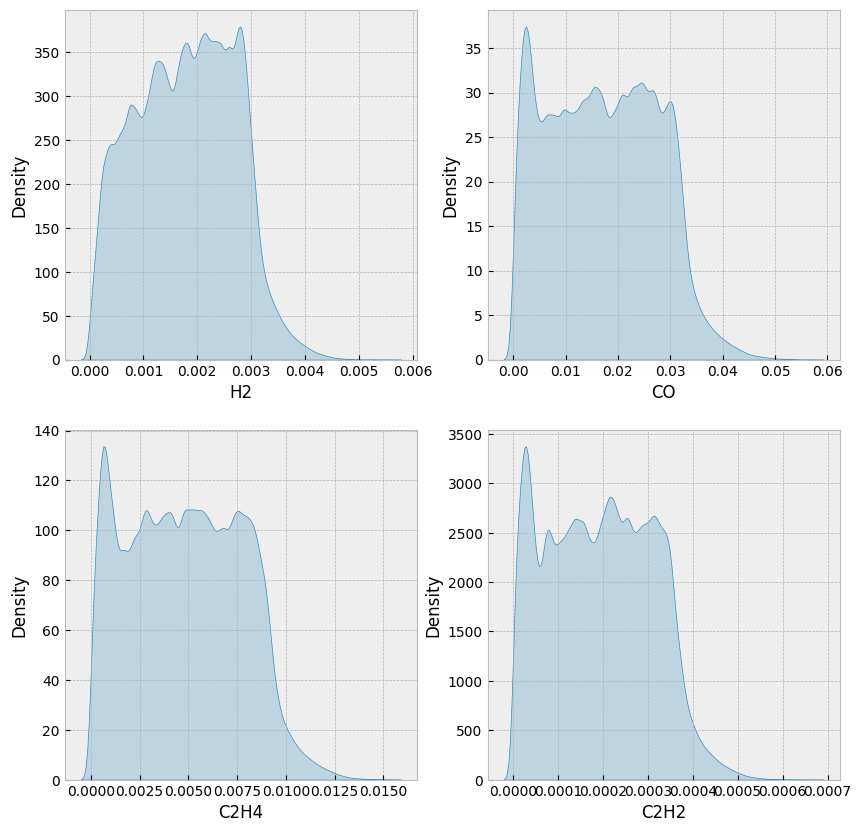

In [8]:
pl, axl = plt.subplots(2, 2, figsize=(10,10))

sns.kdeplot(ax = axl[0,0], data=data[gases[0]], fill=True)
sns.kdeplot(ax = axl[0,1], data=data[gases[1]], fill=True)
sns.kdeplot(ax = axl[1,0], data=data[gases[2]], fill=True)
sns.kdeplot(ax = axl[1,1], data=data[gases[3]], fill=True)
# plt.show()

Text(0, 0.5, 'Тип газа')

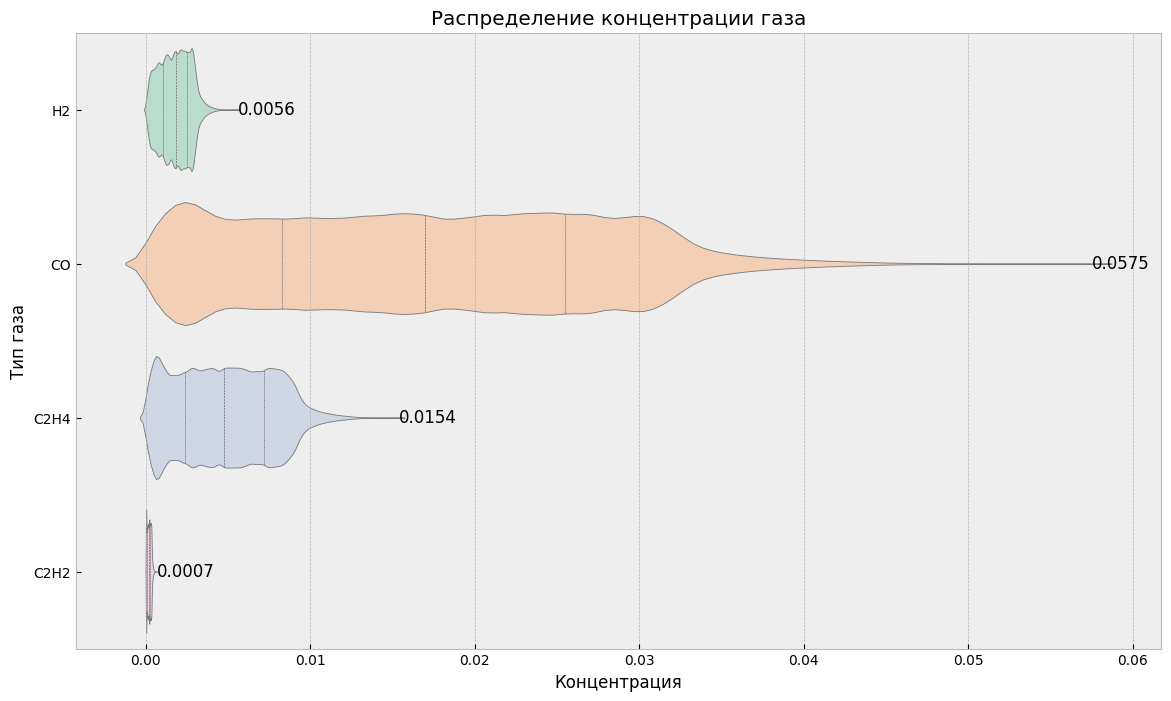

In [9]:
plt.figure(figsize=(14, 8))
ax = sns.violinplot(data=data[gases], orient='h', inner="quartile", palette="Pastel2")

for i, val in enumerate(gases):
    max_val = max_gases[val]
    plt.text(max_val, i, f"{max_val:.4f}", va='center', ha='left', fontsize=12, color='black')


plt.title('Распределение концентрации газа')
plt.xlabel('Концентрация')
plt.ylabel('Тип газа')

Text(0, 0.5, 'Тип газа')

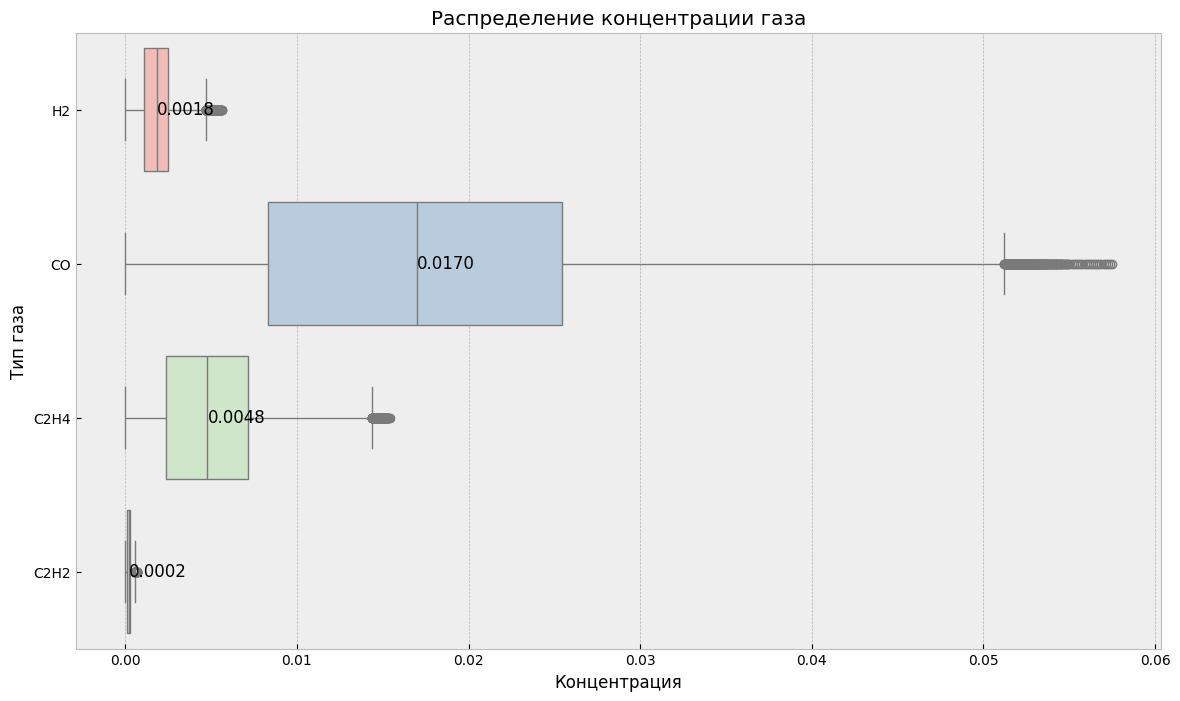

In [10]:
plt.figure(figsize=(14, 8))
axb = sns.boxplot(data=data[gases], orient='h', palette="Pastel1")

for i, gases in enumerate(gases):
    median_val = median_gases[gases]
    plt.text(median_val, i, f"{median_val:.4f}", va='center', ha='left', fontsize=12, color='black')


plt.title('Распределение концентрации газа')
plt.xlabel('Концентрация')
plt.ylabel('Тип газа')

In [11]:
random_id = np.random.choice(data['id'].unique(), size=10, replace=False).tolist()
data.replace([np.inf, -np.inf], np.nan, inplace=True)

random_sample = data.set_index('id').loc[random_id]

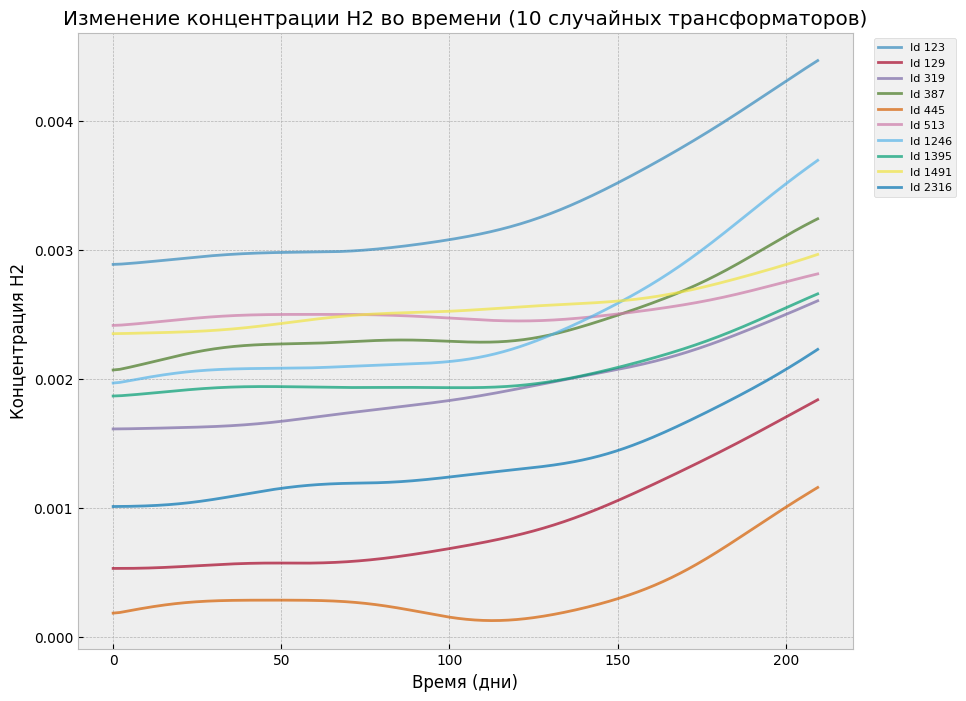

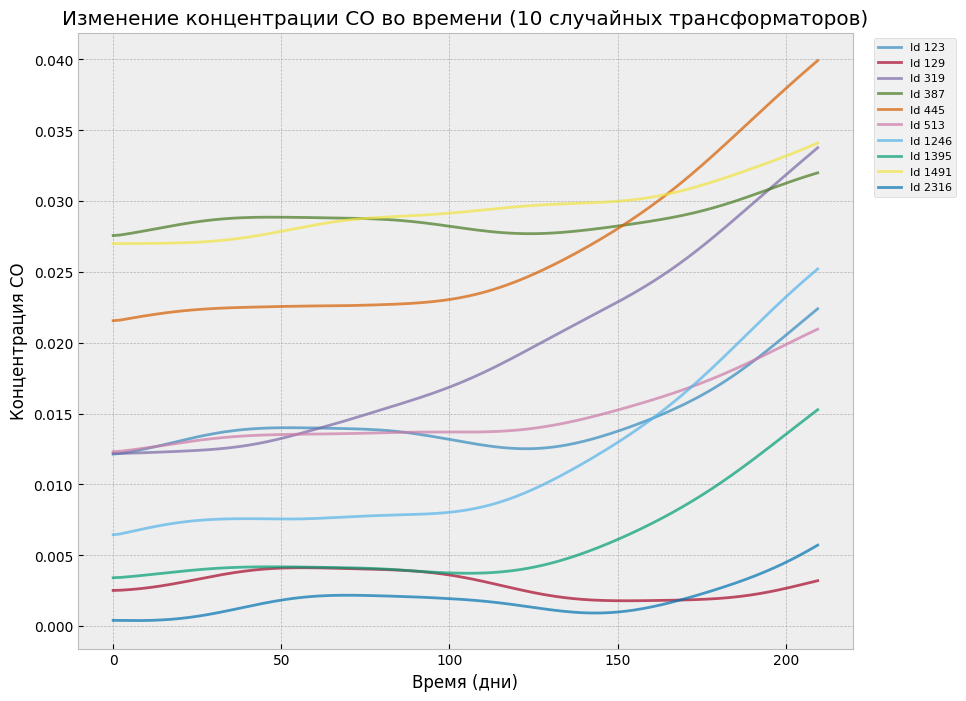

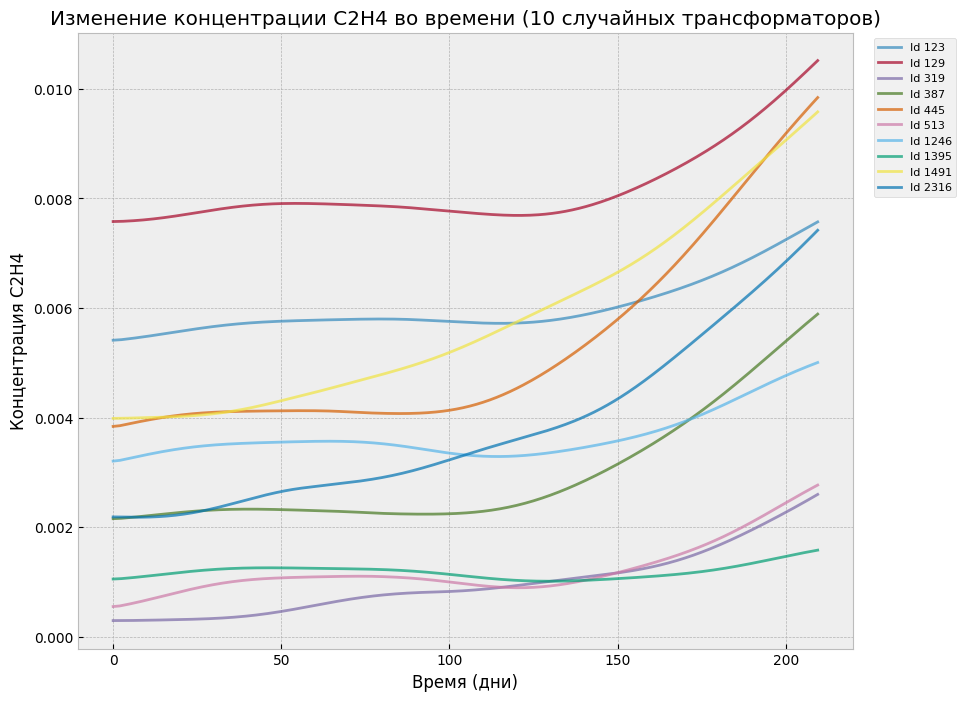

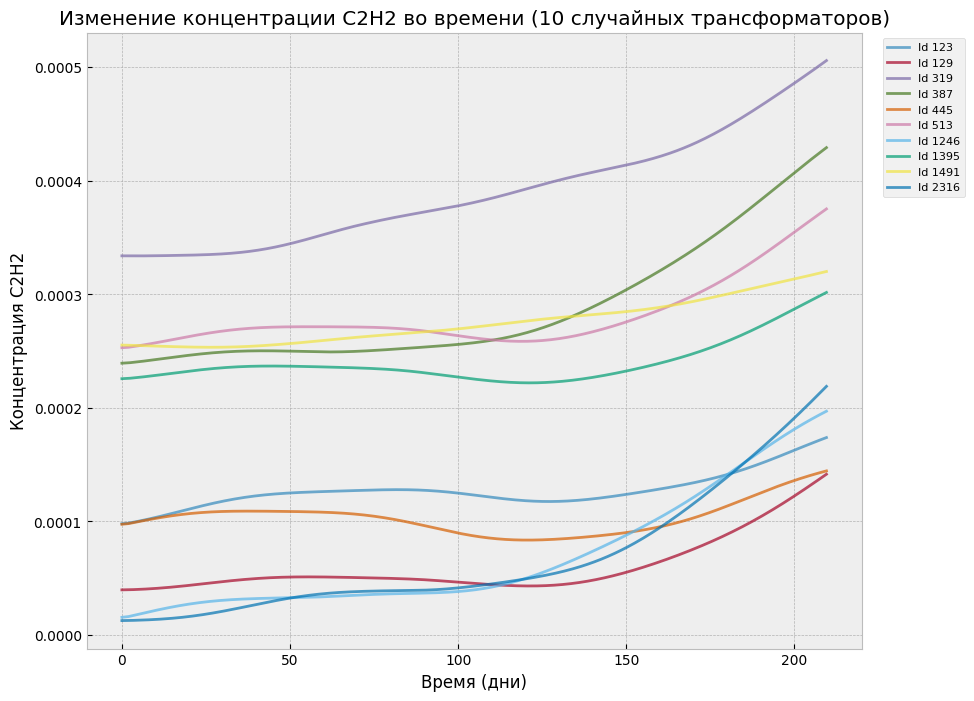

In [12]:
gases = ["H2", "CO", "C2H4", "C2H2"] 
for gas in gases:
    plt.figure(figsize=(10, 8))
    
    new_dt = (random_sample.groupby('id').apply(lambda t:
                                     pd.DataFrame(
                                         {'Время (дни)':t['time_days'].values,
                                          'Концентрация': t[gas].rolling(window=5, min_periods=1).mean().values,
                                          'Id': f"Id {t.name}"}
                                     )).reset_index(drop=True)
             )
    ax = sns.lineplot(data=new_dt, x='Время (дни)', y='Концентрация', hue='Id', alpha=0.7)

    plt.title(f"Изменение концентрации {gas} во времени (10 случайных трансформаторов)")
    plt.xlabel("Время (дни)")
    plt.ylabel(f"Концентрация {gas}")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))

    plt.show()
    

In [13]:
isnull_val = data.isnull().any()
print(f"NULL значения: \n{isnull_val}")

print("=============================")

isna_val = data.isna().any()

print(f"Na значения: \n{isna_val}")

NULL значения: 
H2              False
CO              False
C2H4            False
C2H2            False
id              False
split           False
predicted       False
time_numeric    False
time_days       False
dtype: bool
Na значения: 
H2              False
CO              False
C2H4            False
C2H2            False
id              False
split           False
predicted       False
time_numeric    False
time_days       False
dtype: bool


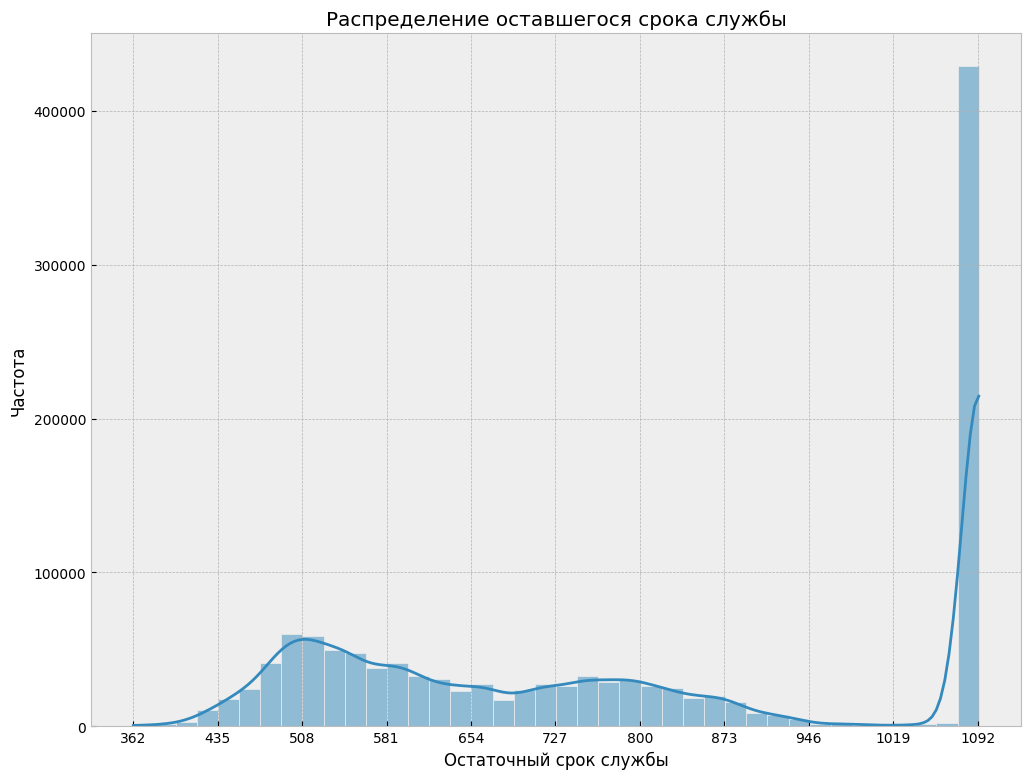

In [14]:
plt.figure(figsize=(12,9))
sns.histplot(data['predicted'], kde=True, bins=40)
plt.title('Распределение оставшегося срока службы')
plt.xlabel('Остаточный срок службы')
plt.ylabel('Частота')

min_rul = data["predicted"].min()
max_rul = data["predicted"].max()
plt.xticks(range(int(min_rul), int(max_rul) + 1, max(1, int((max_rul - min_rul) // 10))))

plt.show()

In [16]:
def get_class_transformer(data):
    data = data.copy()

    new_transform = data['predicted'] == 1093
    threshold = data.loc[~new_transform, 'predicted'].quantile(0.99)

    old_transform = data['predicted'] < threshold

    data['transformer_type'] = np.where(new_transform, 1, 0)

    return data

data = get_class_transformer(data)

data[data['transformer_type'] == 0]

,H2,CO,C2H4,C2H2,id,split,predicted,time_numeric,time_days,transformer_type
1260,0.000247,0.019253,0.000612,0.000147,2782,0,553,0,0.0,0
1261,0.000248,0.019273,0.000615,0.000147,2782,0,553,12,0.5,0
1262,0.000249,0.019294,0.000617,0.000147,2782,0,553,24,1.0,0
1263,0.000251,0.019316,0.000620,0.000147,2782,0,553,36,1.5,0
1264,0.000252,0.019338,0.000623,0.000147,2782,0,553,48,2.0,0
...,...,...,...,...,...,...,...,...,...,...
1259575,0.002824,0.032177,0.009428,0.000331,125,1,799,4980,207.5,0
1259576,0.002831,0.032276,0.009460,0.000331,125,1,799,4992,208.0,0
1259577,0.002838,0.032376,0.009492,0.000332,125,1,799,5004,208.5,0
1259578,0.002845,0.032476,0.009525,0.000332,125,1,799,5016,209.0,0


In [21]:
new = data[data["transformer_type"] == 1]
old = data[data["transformer_type"] == 0]

amount_new = new['id'].nunique()
amount_old = old['id'].nunique()
amount_all = data['id'].nunique()

print(f'Нестабильных трансформаторов: {amount_new}')
print(f'Стабильных трансформаторов: {amount_old}')
print(f'Общее количество трансформаторов: {amount_new + amount_old}, должно быть {amount_all}')

Нестабильных трансформаторов: 1012
Стабильных трансформаторов: 1988
общее количество трансформаторов: 3000, должно быть 3000


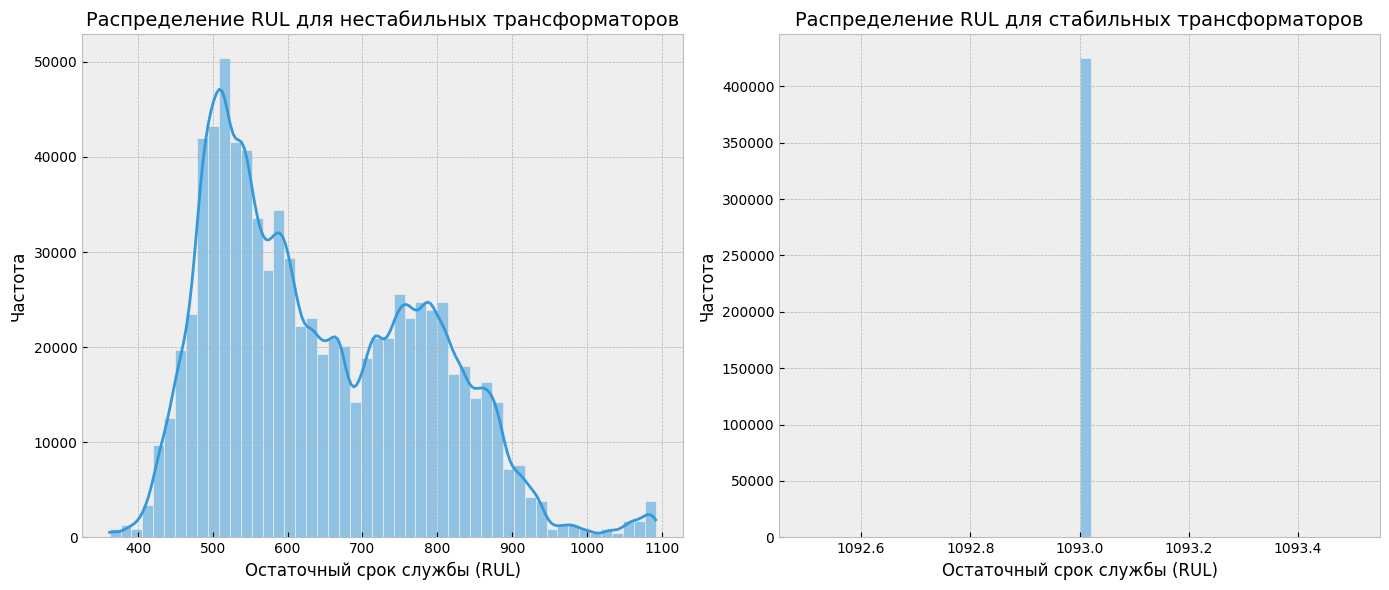

In [22]:
rul_old = old['predicted']
rul_new = new['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Создаем фигуру с двумя подграфиками

# 1. График для старых трансформаторов
sns.histplot(rul_old, kde=True, bins=50, color="#3498db", ax=axes[0])  
axes[0].set_title("Распределение RUL для нестабильных трансформаторов", fontsize=14)  
axes[0].set_xlabel("Остаточный срок службы (RUL)", fontsize=12)  
axes[0].set_ylabel("Частота", fontsize=12)  

# 2. График для новых трансформаторов
sns.histplot(rul_new, kde=True, bins=50, color="#3498db", ax=axes[1])  
axes[1].set_title("Распределение RUL для стабильных трансформаторов", fontsize=14)  
axes[1].set_xlabel("Остаточный срок службы (RUL)", fontsize=12)  
axes[1].set_ylabel("Частота", fontsize=12)  

plt.tight_layout()  
plt.show()  

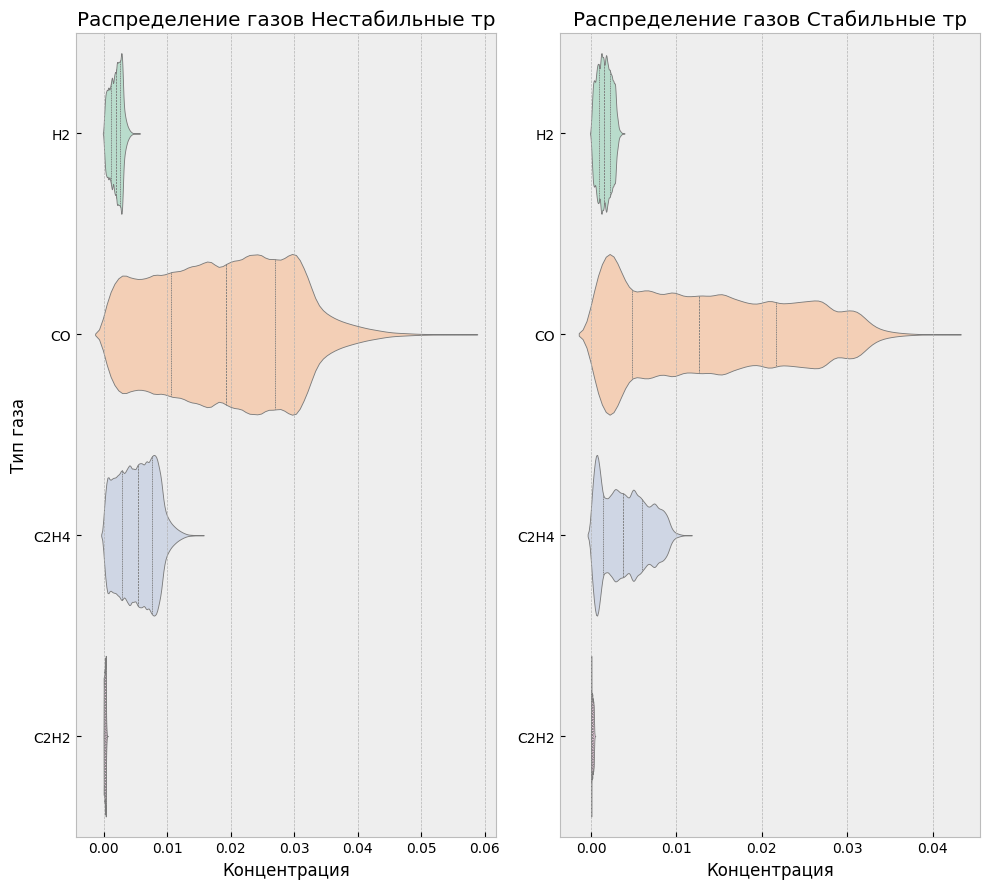

In [31]:
fig, axes = plt.subplots(1,2, figsize=(10, 9))

for ax, (title, df) in zip(axes, [("Нестабильные тр", old), ("Стабильные тр", new)]):
    sns.violinplot(data=df[gases], orient='h', inner="quartile", palette="Pastel2", ax=ax)
    ax.set_title(f'Распределение газов {title}')
    ax.set_xlabel('Концентрация')
    if ax is axes[0]:  
        ax.set_ylabel("Тип газа") 

plt.tight_layout()



In [32]:
id_new = np.random.choice(new['id'].unique(), size=10, replace=False).tolist()
id_old = np.random.choice(old['id'].unique(), size=10, replace=False).tolist()
data.replace([np.inf, -np.inf], np.nan, inplace=True)

random_new = new.set_index('id').loc[id_new]
random_old = old.set_index('id').loc[id_old]

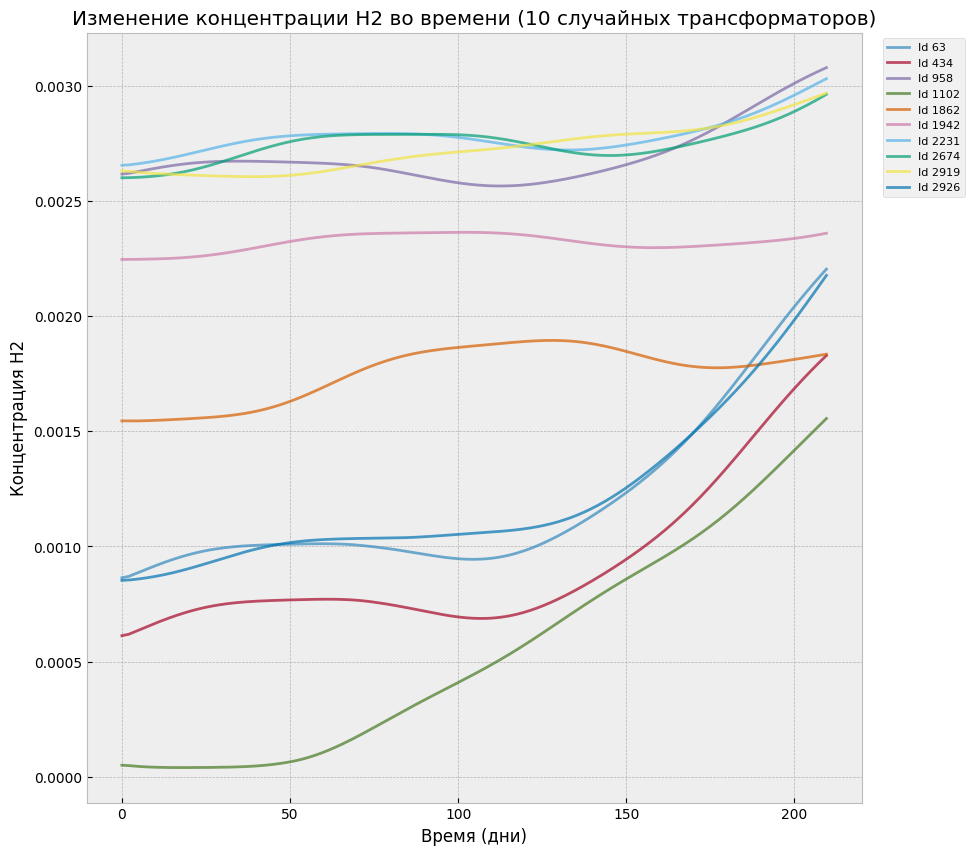

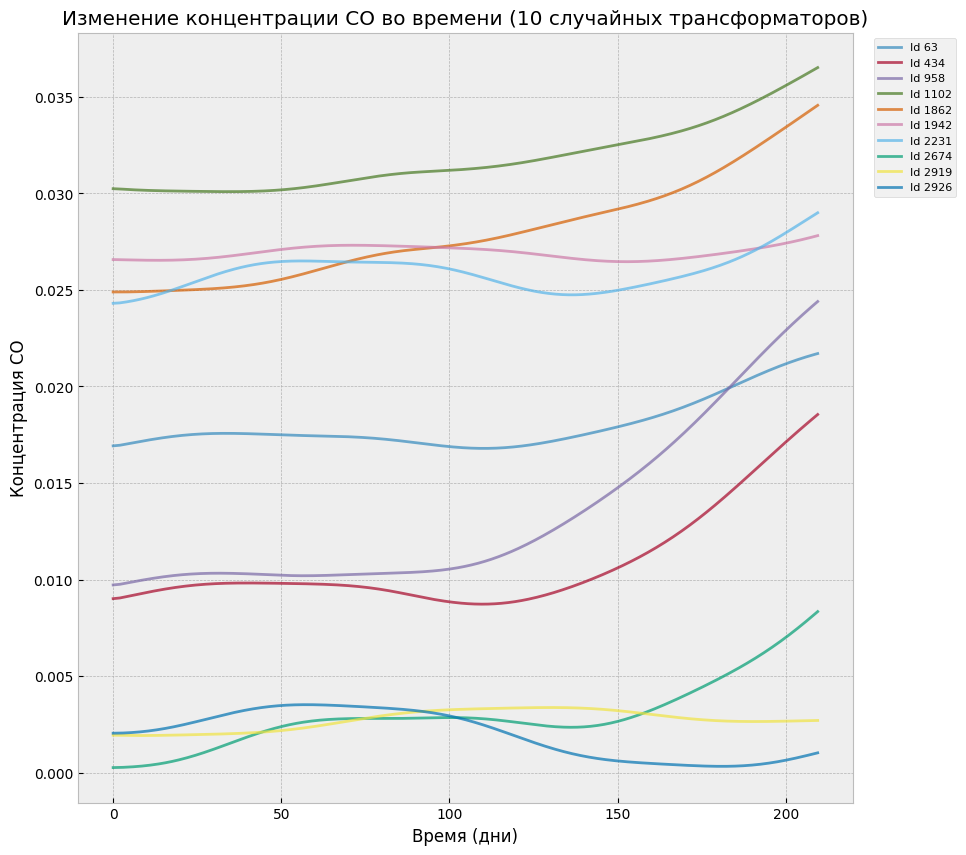

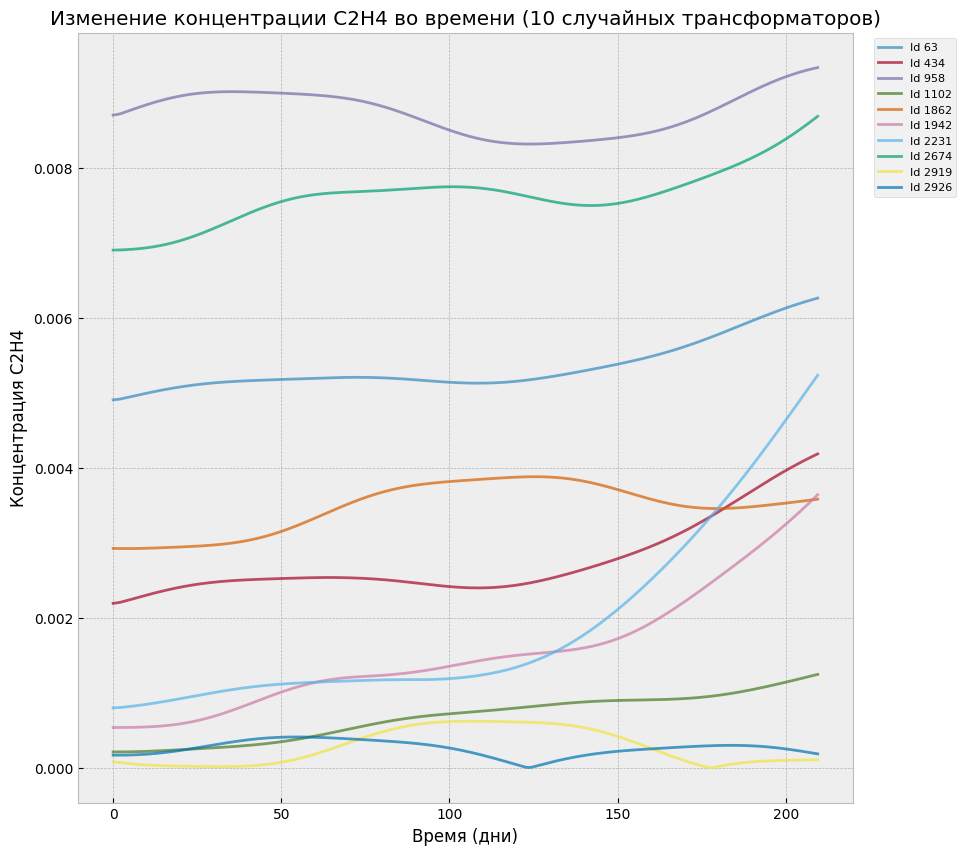

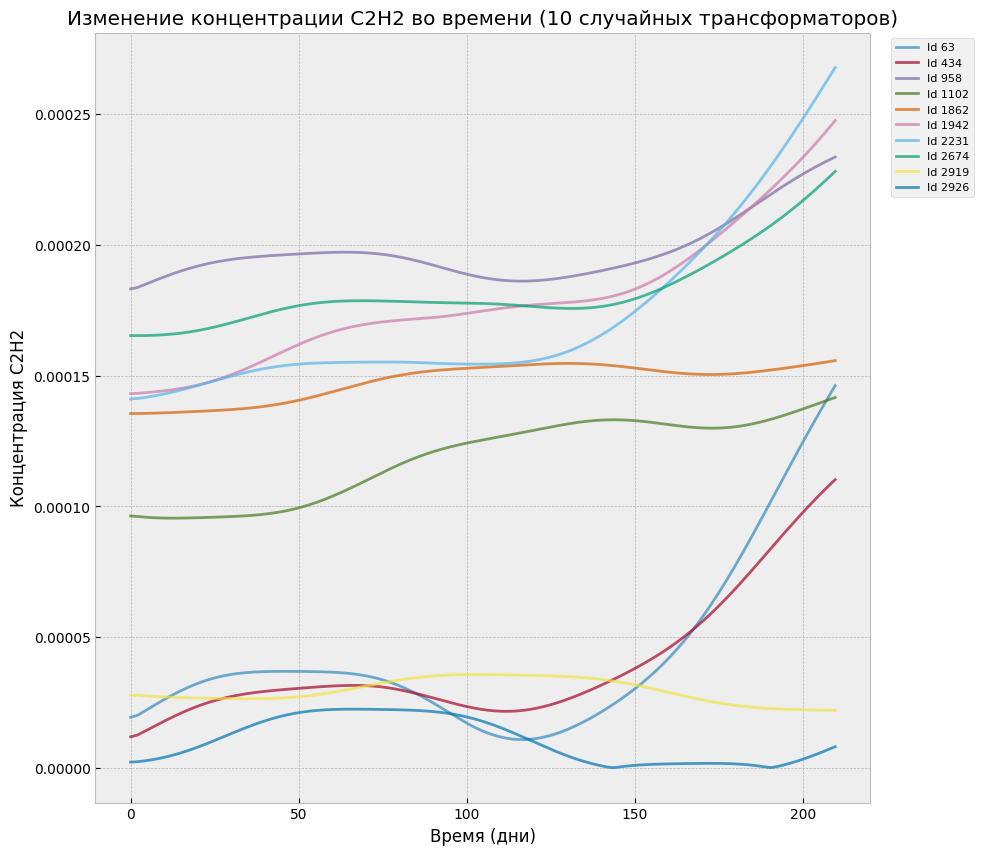

In [34]:
for gas in gases:
    fig, axes = plt.subplots(figsize=(10,10))

    new_dt_rand = (random_new.groupby('id').apply(lambda t:
                                                pd.DataFrame({'Время (дни)':t['time_days'].values,
                                          'Концентрация': t[gas].rolling(window=5, min_periods=1).mean().values,
                                          'Id': f"Id {t.name}"}
                                     )).reset_index(drop=True)
             )

    ax = sns.lineplot(data=new_dt_rand, x='Время (дни)', y='Концентрация', hue='Id', alpha=0.7)

    plt.title(f"Изменение концентрации {gas} во времени (10 стабильных случайных трансформаторов)")
    plt.xlabel("Время (дни)")
    plt.ylabel(f"Концентрация {gas}")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))

    plt.show()

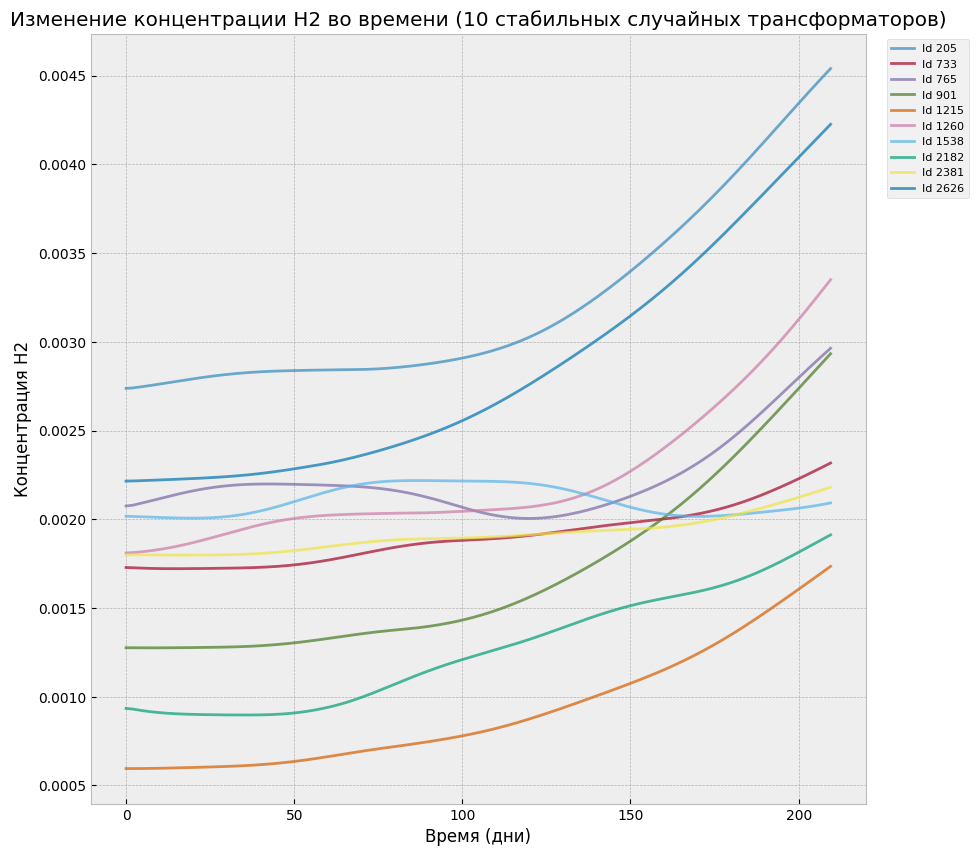

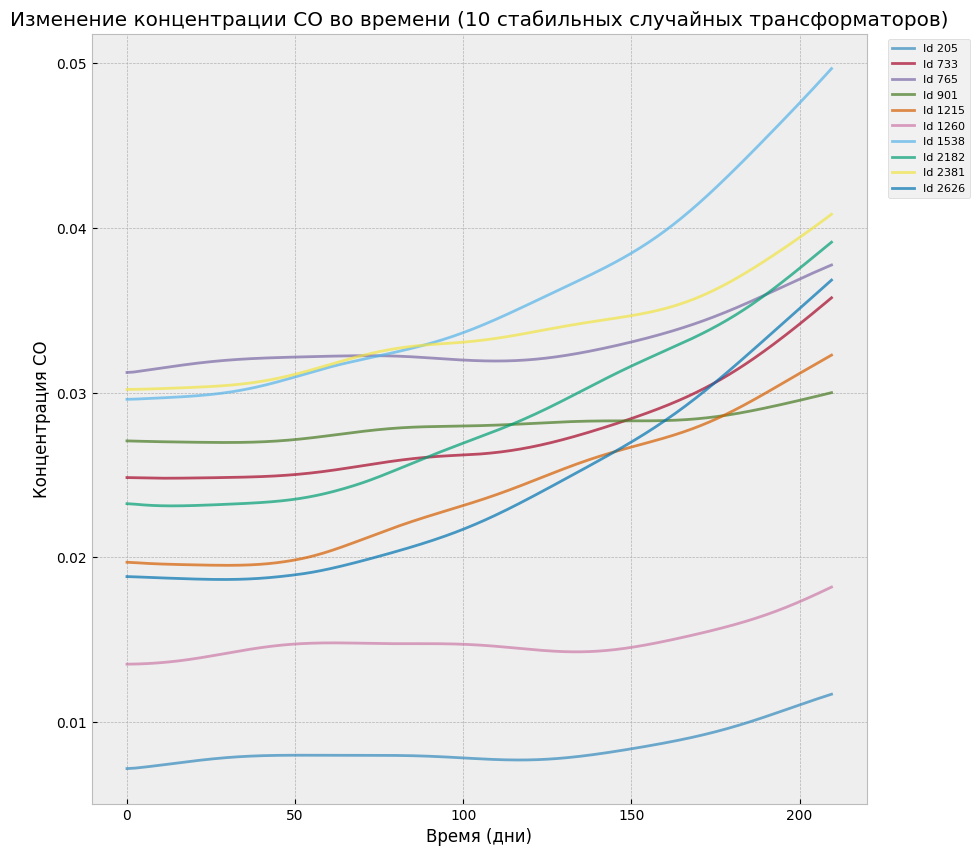

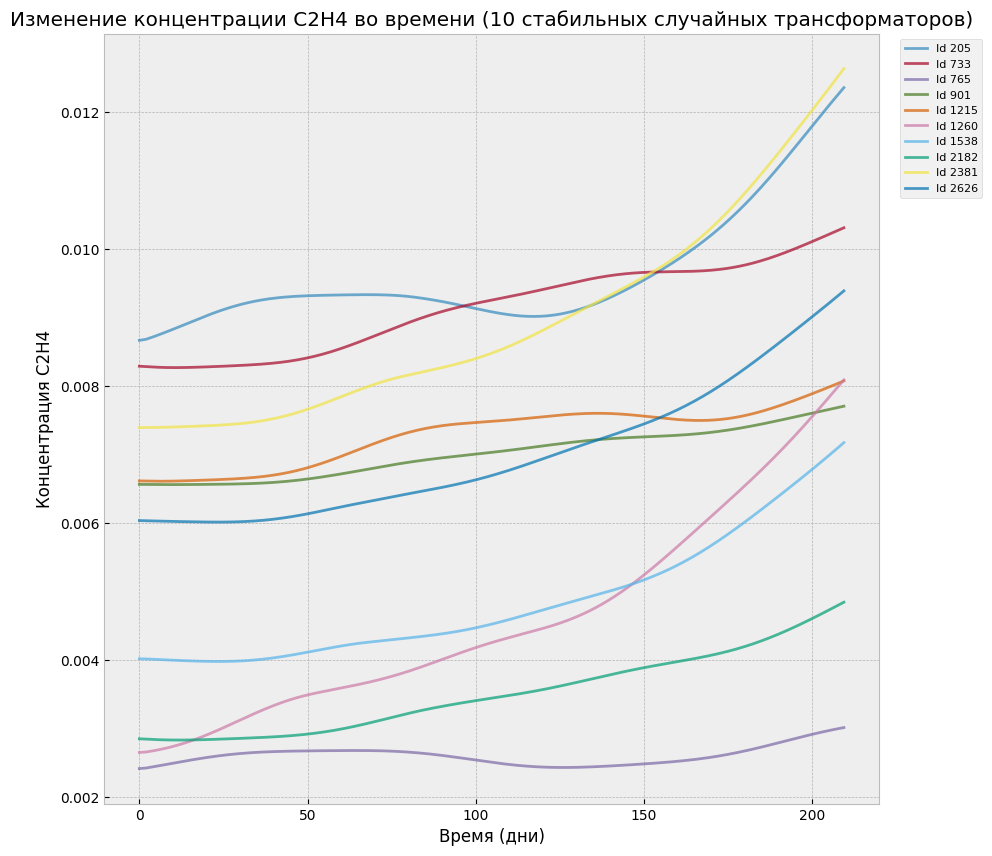

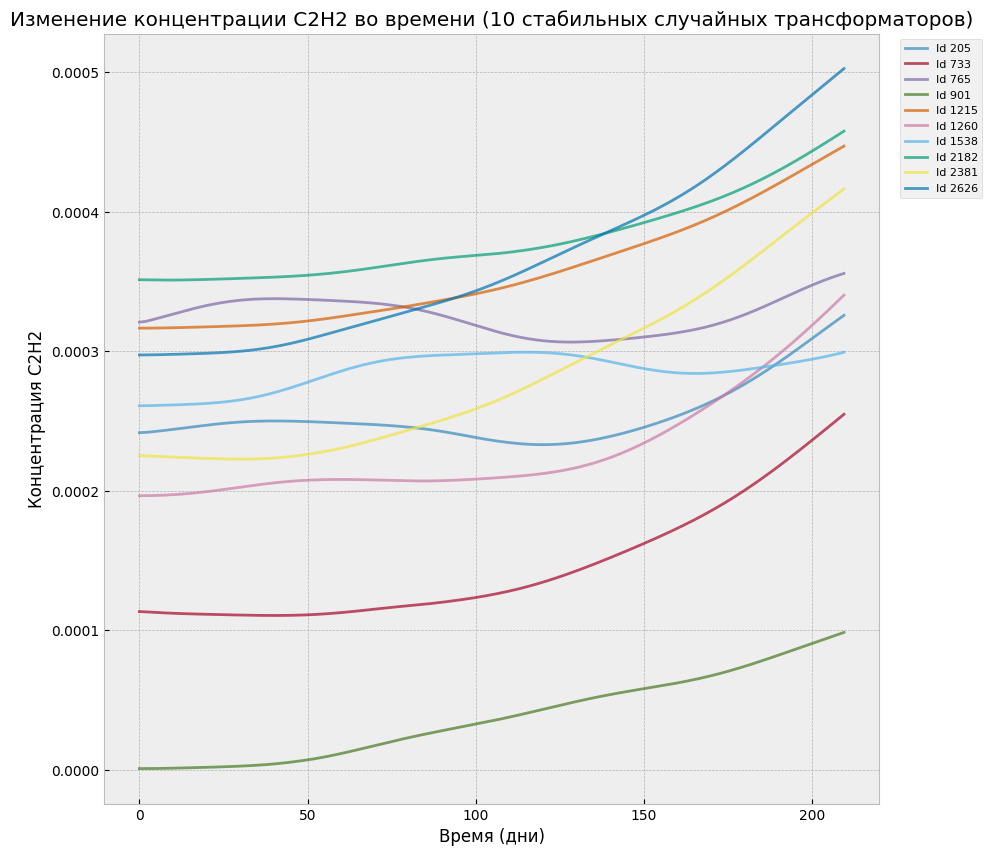

In [35]:
for gas in gases:
    fig, axes = plt.subplots(figsize=(10,10))

    old_dt_rand = (random_old.groupby('id').apply(lambda t:
                                                pd.DataFrame({'Время (дни)':t['time_days'].values,
                                          'Концентрация': t[gas].rolling(window=5, min_periods=1).mean().values,
                                          'Id': f"Id {t.name}"}
                                     )).reset_index(drop=True)
             )

    ax = sns.lineplot(data=old_dt_rand, x='Время (дни)', y='Концентрация', hue='Id', alpha=0.7)

    plt.title(f"Изменение концентрации {gas} во времени (10 стабильных случайных трансформаторов)")
    plt.xlabel("Время (дни)")
    plt.ylabel(f"Концентрация {gas}")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))

    plt.show()